
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E02_sklearn.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Scikit-learn exercises 

---
These are introductory exercises in Machine learning with focus in **scikit-learn** .

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. EDA (*)

In the whole exercise, we will work with the "mpg" dataset from seaborn dataset. Start by loading dataset "mpg" from the ```load_dataset``` method in seaborn module. The goal will be to use linear regression to predict mpg - miles per gallon. 



Linear regression can only handle numbers.
mpg= mile per galen : this is our target
feature:These are the values you use to predict the target. 
1.check the data 
info()
null values: mpg.isnull().sum():Check missing values
.describe() :computes summary statistics for numeric columns:
2. handle missing data: 
fillin():Replaces missing values (NaN) with a specific value (median, mean, 0, or constant).
Pros ✅
Keeps all rows in the dataset (no data loss)
Simple and effective for small number of missing values
Can use median/mean to reduce bias
Cons ❌
Can introduce bias if missing values are not random
Might affect distribution of data slightly

dropna(): Removes rows (or columns) that contain missing values.
Pros ✅
Removes uncertainty — no need to guess missing values
Keeps data “pure” (all values are real)
Cons ❌
Reduces dataset size (data loss)
Can remove too many rows if missing values are frequent

3: remove catagorial in regresiom:
Categorical → “group / type / label”
Examples: country, color, engine type
Numeric → “measured quantity”
Examples: weight, horsepower, MPG
the relevant numeric columns are:
mpg → target
cylinders → numeric or categorical (small number of unique values)
displacement → numeric
horsepower → numeric
weight → numeric
acceleration → numeric
model_year → numeric

I exclude:
origin → categorical
name → string (car name)

4. make y target and x feature
5. Splits your dataset into training data and testing data.
Training data → used to teach the model how features relate to the target.
Testing data → used to evaluate how well the model predicts unseen data.
We never train and test on the same data — it would give overly optimistic results.
6. 



In [42]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
mpg = sns.load_dataset('mpg')
print(f"head:\n{mpg.head(5)}")
#print(f"null values:\n{mpg.isnull().sum()}")
#print(f"describe:\n{mpg.describe()}")
#print(f"origin value counts:\n{mpg['origin'].value_counts()}")

mpg = mpg.dropna()
print(f"null values after dropna:\n{mpg.isnull().sum()}")


head:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
null values after dropna:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [43]:
# Select relevant numeric columns
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

# Get statistical summary
print(f"statistical summary:\n{mpg[numeric_cols].describe()}")
mpg = pd.get_dummies(mpg, columns=['origin'], drop_first=True)
mpg = mpg.drop('name', axis=1)
print(mpg.head(3))

statistical summary:
              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.445918    5.471939    194.411990  104.469388  2977.584184   
std      7.805007    1.705783    104.644004   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    392.000000  392.000000  
mean      15.541327   75.979592  
std        2.758864    3.683737  
min        8.000000   70.000000  
25%       13.775000   73.000000  
50%       15.500000   76.000000  
75%       17.025000   79.000000  
max       24.800000   82.000000  
    mpg  cylinders  disp

X shape: (392, 8)
y shape: (392,)
Actual MPG: 26.0, Predicted MPG: 26.62
Actual MPG: 21.6, Predicted MPG: 26.90
Actual MPG: 36.1, Predicted MPG: 34.27
Actual MPG: 26.0, Predicted MPG: 24.44
Actual MPG: 27.0, Predicted MPG: 28.24


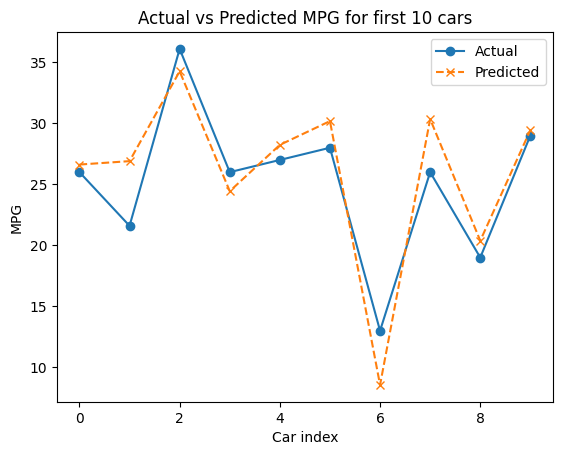

In [44]:
# Target
y = mpg['mpg']

# Features
X = mpg.drop('mpg', axis=1)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")   

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model=LinearRegression()
# Train model
model.fit(x_train, y_train)
predictions = model.predict(x_test)
# Compare first 5 predictions with actual values
for actual, pred in zip(y_test[:5], predictions[:5]):
    print(f"Actual MPG: {actual}, Predicted MPG: {pred:.2f}")

import matplotlib.pyplot as plt

plt.plot(range(10), y_test.values[:10], 'o-', label='Actual')
plt.plot(range(10), predictions[:10], 'x--', label='Predicted')
plt.xlabel('Car index')
plt.ylabel('MPG')
plt.title('Actual vs Predicted MPG for first 10 cars')
plt.legend()
plt.show()


&nbsp; a) Start by doing some initial EDA such as info(), describe() and figure out what you want to do with the missing values.

&nbsp; b) Use describe only on those columns that are relevant to get statistical information from. 

&nbsp; c) Make some plots on some of the columns that you find interesting.

&nbsp; d) Check if there are any columns you might want to drop. 

<details>

<summary>Answer</summary>

a) I have chosen to drop the rows, but it doesn't neccessary have to be the best method. Maybe some NaNs should be filled somehow?

b)
|      |      mpg |   cylinders |   displacement |   horsepower |   weight |   acceleration |
|:-----|---------:|------------:|---------------:|-------------:|---------:|---------------:|
| mean | 23.4459  |     5.47194 |        194.412 |     104.469  | 2977.58  |       15.5413  |
| std  |  7.80501 |     1.70578 |        104.644 |      38.4912 |  849.403 |        2.75886 |
| min  |  9       |     3       |         68     |      46      | 1613     |        8       |
| 25%  | 17       |     4       |        105     |      75      | 2225.25  |       13.775   |
| 50%  | 22.75    |     4       |        151     |      93.5    | 2803.5   |       15.5     |
| 75%  | 29       |     8       |        275.75  |     126      | 3614.75  |       17.025   |
| max  | 46.6     |     8       |        455     |     230      | 5140     |       24.8     |


c) Here are some example plots

<img src="../data/EDA_mpg.png" height="400"/>

d) I have chosen to drop the columns origin and name. Think yourself if it is reasonable and feel free to experiment. Also there might be some domain experts in our class, that you can ask. 

</details>

---

## 1. Train|test split (*)

We want to predict the "mpg", split up X and y, and perform train|test split using scikit-learn. Choose test_size of 0.2 and random_state 42. Control the shapes of each X_train, X_test, y_train, y_test.  

<details>

<summary>Answer</summary>

Do a manual calculation to check against the shapes after train|test split. 

</details>

---

## 2. Function for evaluation (*)

Create a function for training a regression model, predicting and computing the metrics MAE, MSE, RMSE. It should take in parameters of X_train, X_test, y_train, y_test, model. Now create a linear regression model using scikit-learns ```LinearRegression()``` (OLS normal equation with SVD) and call your function to get metrics. 

<details>

<summary>Answer</summary>

MAE 2.50

MSE 10.50

RMSE 3.24

</details>

---
## 3. Compare models (*)

Create the following models 
- Linear regression (SVD)
- Linear regression (SVD) with scaled data (feature standardization)
- Polynomial linear regression with degree 1
- Polynomial linear regression with degree 2
- Polynomial linear regression with degree 3

Make a DataFrame with evaluation metrics and model. Which model performed overall best?

<details>

<summary>Answer</summary>

|      |   Linear regr. SVD |   Linear regr. SVD scaled |   Linear regr. SGD |   Polynom. regr. deg 1 |   Polynom. regr. deg 2 |   Polynom. regr. deg 3 |
|:-----|-------------------:|--------------------------:|-------------------:|-----------------------:|-----------------------:|-----------------------:|
| mae  |            2.50386 |                   2.50386 |            2.53515 |                2.50386 |                1.98048 |                2.11788 |
| mse  |           10.5024  |                  10.5024  |           10.8908  |               10.5024  |                7.41986 |                9.27353 |
| rmse |            3.24074 |                   3.24074 |            3.30012 |                3.24074 |                2.72394 |                3.04525 |

</details>

---


## 4. Further explorations (**)

Feel free to further explore the dataset, for example you could choose to 
- drop different columns
- find out feature importance in polynomial models
- fine tune further for a specific model by exploring hyperparameters (check documentation which type of parameters that can be changed)

---

Kokchun Giang, Raphael Korsoski

---